# AI Project — Static Maze Solver

##  Section 1 — Imports & Setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import deque
import random
import time

random.seed(42)
np.random.seed(42)

print("Libraries loaded successfully.")

✅ Libraries loaded successfully.


## 🗺️ Section 2 — Maze Definition

The maze is a 10×10 NumPy array where:
- `0` = Walkable cell
- `1` = Solid wall
- **Start**: `(0, 0)` — top-left
- **Goal**: `(9, 9)` — bottom-right

In [6]:
maze = np.array([
    [0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
    [1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [0, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [1, 1, 0, 1, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 0, 1, 1, 0, 1, 1, 0, 0],
])

START = (0, 0)
GOAL  = (9, 9)
ROWS, COLS = maze.shape

print(f"Maze shape : {maze.shape}")
print(f"Start      : {START}")
print(f"Goal       : {GOAL}")
print(f"Wall cells : {np.sum(maze == 1)}")
print(f"Free cells : {np.sum(maze == 0)}")
print("\nMaze (0=path, 1=wall):")
print(maze)

Maze shape : (10, 10)
Start      : (0, 0)
Goal       : (9, 9)
Wall cells : 37
Free cells : 63

Maze (0=path, 1=wall):
[[0 0 1 0 0 0 1 0 0 0]
 [1 0 1 0 1 0 1 0 1 0]
 [0 0 0 0 1 0 0 0 1 0]
 [0 1 1 0 1 1 1 0 1 0]
 [0 0 0 0 0 0 1 0 0 0]
 [1 1 0 1 1 0 1 1 1 0]
 [0 0 0 0 0 0 0 0 1 0]
 [0 1 1 1 1 1 0 1 1 0]
 [0 0 0 0 0 0 0 0 0 0]
 [1 1 0 1 1 0 1 1 0 0]]


## 🔵 Section 3 — BFS (Breadth-First Search)

BFS explores the maze level-by-level using a **queue (FIFO)**. It is:
- ✅ **Complete** — always finds a path if one exists
- ✅ **Optimal** — guaranteed to return the **shortest** path on unweighted grids
- ⚠️ **Memory intensive** — stores all visited nodes: O(b^d)

In [7]:
def bfs(grid, start, goal):
    """
    Breadth-First Search on a 2D grid.
    Returns the shortest path as a list of (row, col) tuples.
    Returns an empty list if no path exists.
    """
    queue   = deque([[start]])   # Each element is a full path
    visited = {start}

    while queue:
        path   = queue.popleft()
        r, c   = path[-1]

        # Goal check
        if (r, c) == goal:
            return path

        # Expand neighbours (Up, Down, Left, Right)
        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nr, nc = r + dr, c + dc
            if (0 <= nr < ROWS and
                0 <= nc < COLS and
                grid[nr][nc] == 0 and
                (nr, nc) not in visited):
                visited.add((nr, nc))
                queue.append(path + [(nr, nc)])

    return []   # No path found


# ── Run BFS ──────────────────────────────────────────────────────────────────
t0 = time.perf_counter()
bfs_path = bfs(maze, START, GOAL)
bfs_time = (time.perf_counter() - t0) * 1000

if bfs_path:
    print(f"✅ BFS found a path!")
    print(f"   Path length : {len(bfs_path) - 1} steps")
    print(f"   Time elapsed: {bfs_time:.3f} ms")
    print(f"   Path coords : {bfs_path}")
else:
    print("❌ BFS found no path.")

✅ BFS found a path!
   Path length : 18 steps
   Time elapsed: 0.273 ms
   Path coords : [(0, 0), (0, 1), (1, 1), (2, 1), (2, 2), (2, 3), (3, 3), (4, 3), (4, 4), (4, 5), (5, 5), (6, 5), (6, 6), (7, 6), (8, 6), (8, 7), (8, 8), (9, 8), (9, 9)]


## 🔴 Section 4 — Genetic Algorithm (GA)

The GA mimics **biological evolution** to optimise a sequence of moves:

| Component | Design Choice |
|-----------|---------------|
| Chromosome | Array of 60 integers, each ∈ {0,1,2,3} |
| Gene meaning | 0=Up, 1=Right, 2=Down, 3=Left |
| Fitness | `1/(manhattan_dist+1) + 1000 if goal reached` |
| Selection | Top 50% survive each generation |
| Crossover | Single-point |
| Mutation | 5% per gene, random new direction |

In [17]:
# ── GA Configuration ─────────────────────────────────────────────────────────
DIRECTIONS    = [(-1, 0), (0, 1), (1, 0), (0, -1)]   # Up Right Down Left
CHROM_LEN     = 60
POP_SIZE      = 200
GENERATIONS   = 500
MUTATION_RATE = 0.05


def simulate(chromosome):
    """
    Execute a chromosome from START.
    Invalid moves (walls / out-of-bounds) are silently ignored.
    Returns: (final_row, final_col, list_of_visited_cells)
    """
    r, c = START
    visited = [(r, c)]
    for gene in chromosome:
        dr, dc = DIRECTIONS[gene]
        nr, nc = r + dr, c + dc
        if 0 <= nr < ROWS and 0 <= nc < COLS and maze[nr][nc] == 0:
            r, c = nr, nc
            visited.append((r, c))
    return r, c, visited


def fitness(chromosome):
    """
    Fitness = inverse Manhattan distance to goal.
    Bonus of +1000 if the goal is actually reached.
    """
    r, c, _ = simulate(chromosome)
    dist  = abs(r - GOAL[0]) + abs(c - GOAL[1])
    bonus = 1000 if (r, c) == GOAL else 0
    return 1.0 / (dist + 1) + bonus


def run_ga():
    """Run the full genetic algorithm and return the best chromosome found."""
    # Initialise random population
    population = [
        np.random.randint(0, 4, CHROM_LEN).tolist()
        for _ in range(POP_SIZE)
    ]

    best_chromosome = None
    best_fitness    = -1
    history         = []          # track best fitness per generation

    for gen in range(GENERATIONS):
        # Evaluate & rank
        scored = sorted(population, key=fitness, reverse=True)
        top    = scored[:POP_SIZE // 2]

        top_fit = fitness(top[0])
        history.append(top_fit)

        if top_fit > best_fitness:
            best_fitness    = top_fit
            best_chromosome = top[0][:]

        # Early stop if goal reached
        if best_fitness >= 1000:
            print(f"   🎯 Goal reached at generation {gen + 1}!")
            break

        # Reproduce: crossover + mutation
        children = []
        while len(children) < POP_SIZE - len(top):
            p1, p2   = random.choices(top, k=2)
            point    = random.randint(1, CHROM_LEN - 1)
            child    = p1[:point] + p2[point:]
            child    = [
                g if random.random() > MUTATION_RATE else random.randint(0, 3)
                for g in child
            ]
            children.append(child)

        population = top + children

    return best_chromosome, best_fitness, history


# ── Run GA ───────────────────────────────────────────────────────────────────
print("Running Genetic Algorithm...")
t0 = time.perf_counter()
best_chrom, best_fit, fit_history = run_ga()
ga_time = (time.perf_counter() - t0) * 1000

_, ga_final, ga_path = simulate(best_chrom)
ga_dist = abs(ga_final[0] - GOAL[0]) + abs(ga_final[1] - GOAL[1])

print(f"\n✅ GA complete!")
print(f"   Best fitness     : {best_fit:.4f}")
print(f"   Final position   : {ga_final}")
print(f"   Manhattan dist   : {ga_dist}")
print(f"   Reached goal     : {ga_final == GOAL}")
print(f"   Path length      : {len(ga_path) - 1} steps")
print(f"   Time elapsed     : {ga_time:.1f} ms")

Running Genetic Algorithm...
   🎯 Goal reached at generation 7!


TypeError: 'int' object is not subscriptable

## 📈 Section 5 — GA Fitness Convergence Plot

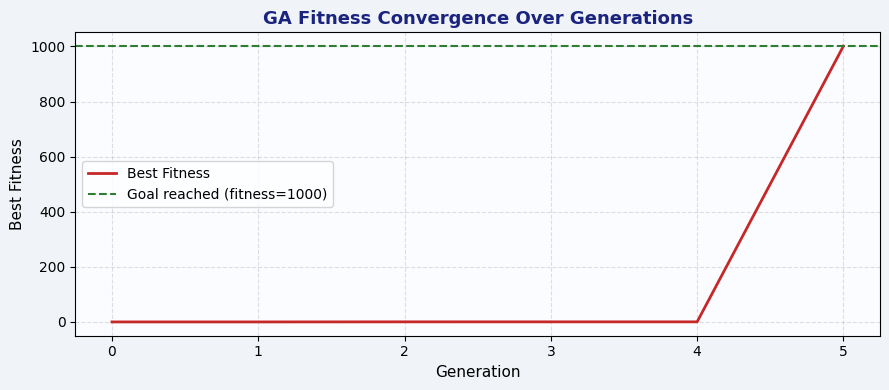

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor('#F0F4F8')
ax.set_facecolor('#FAFCFF')

ax.plot(fit_history, color='#C62828', linewidth=2, label='Best Fitness')
ax.axhline(y=1000, color='#2E7D32', linestyle='--', linewidth=1.5, label='Goal reached (fitness=1000)')
ax.set_xlabel('Generation', fontsize=11)
ax.set_ylabel('Best Fitness', fontsize=11)
ax.set_title('GA Fitness Convergence Over Generations', fontsize=13, fontweight='bold', color='#1A237E')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

## 🖼️ Section 6 — Maze Visualization (BFS vs GA)

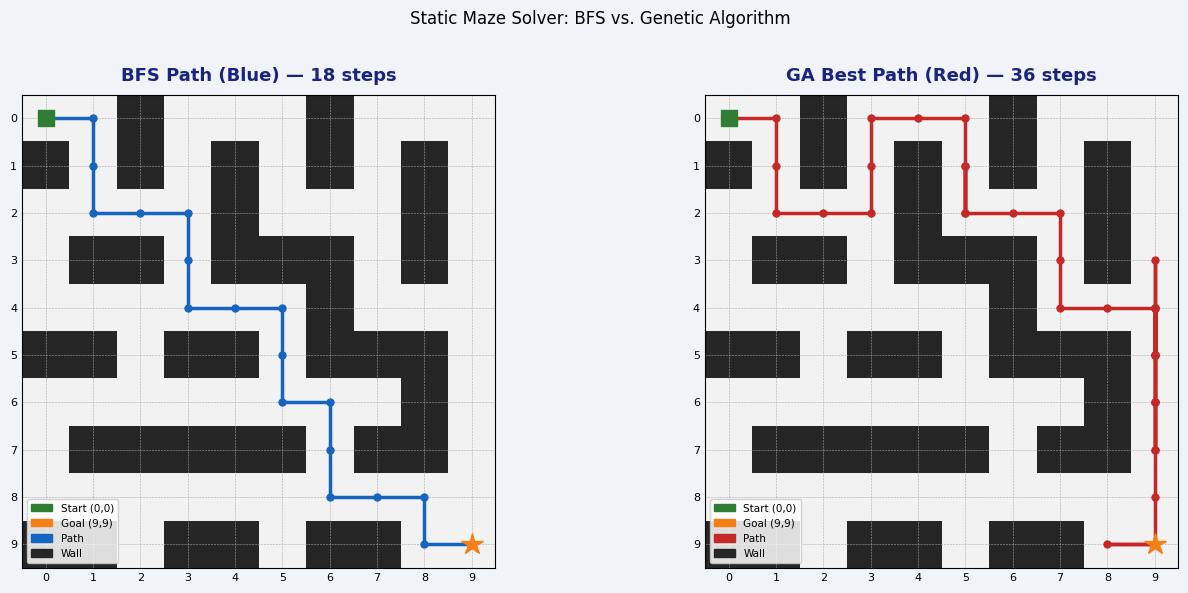

Figure saved as maze_visualization.png


In [13]:
def draw_maze(ax, path, path_color, title):
    """Draw the maze with a given path on a matplotlib Axes."""
    # Build RGB image from maze
    img = np.zeros((*maze.shape, 3))
    for r in range(ROWS):
        for c in range(COLS):
            img[r, c] = [0.15, 0.15, 0.15] if maze[r, c] == 1 else [0.95, 0.95, 0.95]
    ax.imshow(img, origin='upper')

    # Draw path line
    if path:
        py = [p[0] for p in path]
        px = [p[1] for p in path]
        ax.plot(px, py, color=path_color, linewidth=2.5, zorder=3)
        ax.plot(px[1:-1], py[1:-1], 'o', color=path_color, markersize=5, zorder=4)

    # Start / Goal markers
    ax.plot(START[1], START[0], 's', color='#2E7D32', markersize=12, zorder=5)
    ax.plot(GOAL[1],  GOAL[0],  '*', color='#F57F17', markersize=16, zorder=5)

    ax.set_title(title, fontsize=13, fontweight='bold', color='#1A237E', pad=10)
    ax.set_xticks(range(COLS))
    ax.set_yticks(range(ROWS))
    ax.set_xticklabels(range(COLS), fontsize=8)
    ax.set_yticklabels(range(ROWS), fontsize=8)
    ax.grid(True, color='#AAAAAA', linewidth=0.4, linestyle='--')
    ax.tick_params(length=0)

    # Legend
    handles = [
        mpatches.Patch(color='#2E7D32', label='Start (0,0)'),
        mpatches.Patch(color='#F57F17', label='Goal (9,9)'),
        mpatches.Patch(color=path_color, label='Path'),
        mpatches.Patch(color='#262626', label='Wall'),
    ]
    ax.legend(handles=handles, loc='lower left', fontsize=7.5, framealpha=0.85)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#F0F4F8')

draw_maze(axes[0], bfs_path, '#1565C0', f'BFS Path (Blue) — {len(bfs_path)-1} steps')
draw_maze(axes[1], ga_path,  '#C62828', f'GA Best Path (Red) — {len(ga_path)-1} steps')

fig.suptitle(
    'Static Maze Solver: BFS vs. Genetic Algorithm\n'
)
plt.tight_layout()
plt.savefig('maze_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as maze_visualization.png")